In [1]:
import os
import torch
import torchvision.transforms as T
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
def view_multi_camera_frame(root_dir, scenario, frame_number):
    """Display frames from all cameras for given scenario and frame number"""
    camera_folders = [
         'Camera_BackRight','Camera_Back', 'Camera_BackLeft',
          'Camera_FrontLeft', 'Camera_Front','Camera_FrontRight' 
    ]
    
    images = []
    for camera in camera_folders:
        img_path = os.path.join(root_dir, camera, scenario, 'Segmented_Data', f'{scenario}_{frame_number:03d}.jpg')
        #img_path = os.path.join(root_dir, camera, scenario, f'{scenario}_{frame_number:03d}.jpg')
       
        if os.path.exists(img_path):
            img = Image.open(img_path)
            img = T.ToTensor()(img)
            images.append(img)
        else:
            print(f"Missing image: {img_path}")
    
    if not images:
        print("No images found for this frame")
        return
        
    grid = make_grid(images, nrow=3, padding=10)
    
    plt.figure(figsize=(15, 10))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    
    for idx, camera in enumerate(camera_folders):
        row = idx // 3
        col = idx % 3
        plt.text(col * grid.shape[2]/3 + 10, 
                row * grid.shape[1]/2 + 20,
                camera.replace('Camera_', ''),
                color='white', 
                backgroundcolor='black')
    
    plt.title(f'Frame {frame_number}\nScenario: {scenario}')
    plt.show()



Enter frame number (e.g., 39 for frame 039): 5


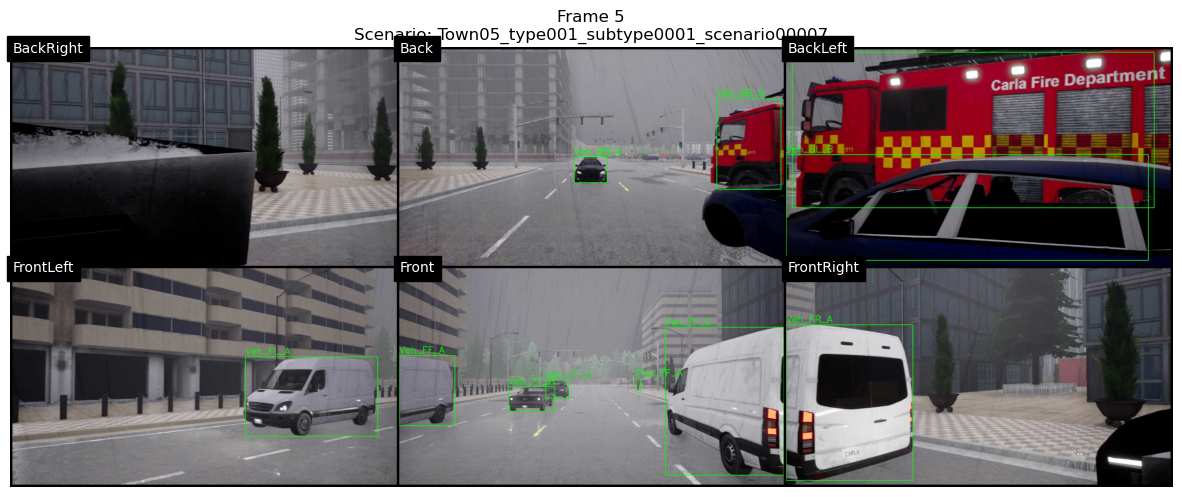

In [3]:
# Usage:
root_dir = 'type1_subtype1_accident/ego_vehicle'
scenario = 'Town05_type001_subtype0001_scenario00007'
frame_num = int(input("Enter frame number (e.g., 39 for frame 039): "))
view_multi_camera_frame(root_dir, scenario, frame_num)